# Component 2 — Adaptive GEV Exceedance Probabilities

C2 reads IFS ensemble forecasts from the IceChunk store, computes rolling
precipitation accumulations over multiple windows, compares against GEV-fitted
CMORPH thresholds stratified by ENSO/IOD phase, and writes exceedance probabilities
to a Zarr store.

**Key modules**: `accumulations`, `exceedance`, `thresholds`

In [ ]:
import os, subprocess, sys, shutil
from pathlib import Path
from datetime import date
from omegaconf import OmegaConf
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def _bootstrap() -> Path:
    """Locate the repo; on Colab, clone + install it first."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "configs" / "default.yaml").exists():
            return p
    repo = Path("/content/gik-icechain")
    if repo.exists() and not (repo / "scripts").exists():
        shutil.rmtree(repo)
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/hashirama21/gik-icechain.git", str(repo)], check=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"{repo}[dev]"], check=True)
    return repo

REPO = _bootstrap()
DATA = REPO / "data"

# Verification and setup of paths
tools_script = REPO / "scripts" / "tools.py"
tools = [sys.executable, str(tools_script)]

try:
    print("Checking prerequisites...")
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO)
    if not (DATA / "cmorph_thresholds").exists():
        subprocess.run([*tools, "download", "--component", "all"], capture_output=True, text=True, check=True, env=env)
        subprocess.run([*tools, "download-thresholds"], check=True, env=env)
        print("Prerequisites downloaded successfully.")
    else:
        print("Prerequisites already present.")
except Exception as e:
    print(f"Setup Error: {e}")

# Initial setup of paths/dates
START = date(2025, 1, 1)
END   = date(2025, 1, 2)

# Helper to load/reload config - important to call after secrets are set
def reload_icechain_config():
    global cfg, STORAGE_OPTIONS
    cfg_path = REPO / "configs/default.yaml"
    if cfg_path.exists():
        cfg = OmegaConf.load(cfg_path)
        endpoint = cfg.outputs.get('endpoint_url')
        STORAGE_OPTIONS = {"endpoint_url": endpoint} if endpoint else {}
        print(f"Config reloaded. Endpoint: {endpoint if endpoint else 'None (Offline Mode)'}")
    else:
        cfg = None
        STORAGE_OPTIONS = {}
        print("Config file not found yet.")

# Run once to initialize, even if file doesn't exist yet
reload_icechain_config()
print(f"Repo root: {REPO}")

In [ ]:
import os
import yaml
from pathlib import Path

try:
    from google.colab import userdata as _colab_userdata
except ImportError:
    _colab_userdata = None

# --- Configuration des Chemins ---
REPO_DIR = REPO  # set by bootstrap cell above
OUTPUT = REPO_DIR / "results/e2e_colab"
RISK_DIR = OUTPUT / "admin1_risk"

# S'assurer que les dossiers de sortie et de config existent
RISK_DIR.mkdir(parents=True, exist_ok=True)
(REPO_DIR / "configs").mkdir(parents=True, exist_ok=True)

# --- Gestion des Secrets (MinIO / AWS) ---
def get_secret(name: str, default: str = "") -> str:
    if _colab_userdata is not None:
        try:
            v = _colab_userdata.get(name)
            if v: return v
        except Exception: pass
    return os.environ.get(name, default)

AWS_ENDPOINT = get_secret("AWS_ENDPOINT_URL")
AWS_KEY      = get_secret("AWS_ACCESS_KEY_ID")
AWS_SECRET   = get_secret("AWS_SECRET_ACCESS_KEY")

LIVE = bool(AWS_ENDPOINT and AWS_KEY and AWS_SECRET)

# --- Génération du fichier Config YAML ---
config_dict = {
    "outputs": {
        "icechunk_store_uri": "s3://gik-icechain/gik-icechain-store" if LIVE else str(OUTPUT / "icechunk-store"),
        "icechunk_store_region": "eu-west-1",
        "endpoint_url": AWS_ENDPOINT if LIVE else "",
        "exceedance_store_uri": "s3://gik-icechain/exceedance-zarr" if LIVE else str(OUTPUT / "exceedance-zarr"),
        "risk_output_dir": str(RISK_DIR) + "/"
    }
}

config_path = REPO_DIR / "configs/default.yaml"
with open(config_path, "w") as f:
    yaml.dump(config_dict, f, default_flow_style=False)

# --- Mise à jour de l'environnement ---
if LIVE:
    os.environ["AWS_ENDPOINT_URL"] = AWS_ENDPOINT
    os.environ["AWS_ACCESS_KEY_ID"] = AWS_KEY
    os.environ["AWS_SECRET_ACCESS_KEY"] = AWS_SECRET

# Synchronize the objects in the 'setup' cell with these changes
if 'reload_icechain_config' in globals():
    reload_icechain_config()

print(f"Configuration terminée !")
print(f"Mode: {'LIVE (MinIO)' if LIVE else 'OFFLINE (Local)'}")
print(f"Fichier généré : {config_path}")
CONFIG = "configs/default.yaml"

## 2.1 Load forecast from IceChunk

In [28]:
def _synthetic_day_ds():
    """Synthetic mm-scale ensemble tp for offline/CI demo (no live store)."""
    rng = np.random.default_rng(0)
    nm, ns, ny, nx = 51, 8, 30, 30
    tp = np.cumsum(rng.exponential(8.0, (nm, ns, ny, nx)), axis=1).astype("float32")
    return xr.Dataset(
        {"tp": (["member", "step", "latitude", "longitude"], tp)},
        coords={"member": np.arange(nm), "step": np.arange(0, ns * 6, 6),
                "latitude": np.linspace(23, -13, ny), "longitude": np.linspace(22, 53, nx)},
    )

from gik_icechain.conversion.icechunk_writer import IceChainStore
LIVE_STORE = bool(cfg.outputs.endpoint_url)
day_ds = None
if LIVE_STORE:
    try:
        store = IceChainStore(
            cfg.outputs.icechunk_store_uri,
            region=cfg.outputs.icechunk_store_region,
            endpoint_url=cfg.outputs.endpoint_url,
        )
        store.create_or_open()
        session = store.readonly_session()
        day_ds = xr.open_zarr(session.store, group="2025-01-01", consolidated=False)[["tp"]]
        b = cfg.component2.spatial.bbox  # [lat_min, lon_min, lat_max, lon_max]
        day_ds = day_ds.sel(latitude=slice(b[2], b[0]), longitude=slice(b[1], b[3]))
    except Exception as exc:
        print(f"Store error ({type(exc).__name__}) -- synthetic demo data")
        day_ds = None
if day_ds is None:
    print("Offline: synthetic mm-scale demo data")
    day_ds = _synthetic_day_ds()

print(day_ds)

2026-06-12 09:50:59 [info     ] icechunk_minio_endpoint        bucket=gik-icechain endpoint=http://20.116.218.195:9000
2026-06-12 09:50:59 [info     ] icechunk_manifest_splitting    dim=step size=1000
2026-06-12 09:50:59 [info     ] icechunk_store_ready           uri=s3://gik-icechain/gik-icechain-store
Store error (ConfigAttributeError) -- synthetic demo data
Offline: synthetic mm-scale demo data
<xarray.Dataset> Size: 1MB
Dimensions:    (member: 51, step: 8, latitude: 30, longitude: 30)
Coordinates:
  * member     (member) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
  * step       (step) int64 64B 0 6 12 18 24 30 36 42
  * latitude   (latitude) float64 240B 23.0 21.76 20.52 ... -10.52 -11.76 -13.0
  * longitude  (longitude) float64 240B 22.0 23.07 24.14 ... 50.86 51.93 53.0
Data variables:
    tp         (member, step, latitude, longitude) float32 1MB 5.439 ... 95.19


/tmp/ipykernel_2541/4019203949.py:24: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  day_ds = xr.open_zarr(session.store, group="2025-01-01", consolidated=False)[["tp"]]


## 2.2 Rolling accumulations

In [29]:
from gik_icechain.exceedance.accumulations import compute_rolling_accumulations

WINDOWS_H = [24, 48, 72]
acc = compute_rolling_accumulations(day_ds, windows_h=WINDOWS_H)
for w in WINDOWS_H:
    key  = f"tp_{w}h"
    vals = acc[key]
    print(f"{key}: shape={vals.shape}  max={float(vals.max()):.4f} m")

2026-06-12 09:51:01 [debug    ] window_accumulation_computed   window_h=24
2026-06-12 09:51:01 [debug    ] window_accumulation_computed   window_h=48
2026-06-12 09:51:01 [debug    ] window_accumulation_computed   window_h=72
tp_24h: shape=(51, 8, 30, 30)  max=175.4500 m
tp_48h: shape=(51, 8, 30, 30)  max=223.0247 m
tp_72h: shape=(51, 8, 30, 30)  max=223.0247 m


## 2.3 Adaptive GEV thresholds

In [22]:
from gik_icechain.exceedance.thresholds import (
    AdaptiveGEVThresholds, ClimateMode,
    classify_enso, classify_iod, get_season,
)

thresholds = AdaptiveGEVThresholds.load(DATA / "cmorph_thresholds")

enso_iod = (pd.read_csv(DATA / "enso_iod_index.csv", parse_dates=["date"])
            .set_index("date").sort_index())
row    = enso_iod.loc[enso_iod.index.asof(pd.Timestamp(START))]  # monthly index
enso   = classify_enso(float(row["nino34_anom"]))
iod    = classify_iod(float(row["dmi"]))
season = get_season(START.month)
mode   = ClimateMode(season, enso, iod)
print(f"Climate mode: {mode.key}")

thr_24h_5y = thresholds.get(24, 5, mode)
print(f"Threshold 24h/5yr: min={float(thr_24h_5y.min()):.3f} max={float(thr_24h_5y.max()):.3f} m")

2026-06-12 09:46:09 [info     ] thresholds_loaded              directory=/content/gik-icechain/data/cmorph_thresholds n_files=252
Climate mode: DJF_la_nina_neutral
Threshold 24h/5yr: min=0.489 max=274.595 m


## 2.4 Exceedance probabilities

In [23]:
from gik_icechain.exceedance.exceedance import (
    compute_exceedance_probabilities, compute_ensemble_confidence,
)

p    = compute_exceedance_probabilities(acc, xr.Dataset({"rp_5y": thr_24h_5y}), 24, 5, "member")
conf = compute_ensemble_confidence(acc, window_h=24, member_dim="member")

print(f"Exceedance: min={float(p.min()):.3f} max={float(p.max()):.3f} mean={float(p.mean()):.3f}")
print(f"Confidence states: {set(int(v) for v in np.unique(conf.values))}")

Exceedance: min=0.000 max=1.000 mean=0.249
Confidence states: {1, 2}


## 2.5 Visualize

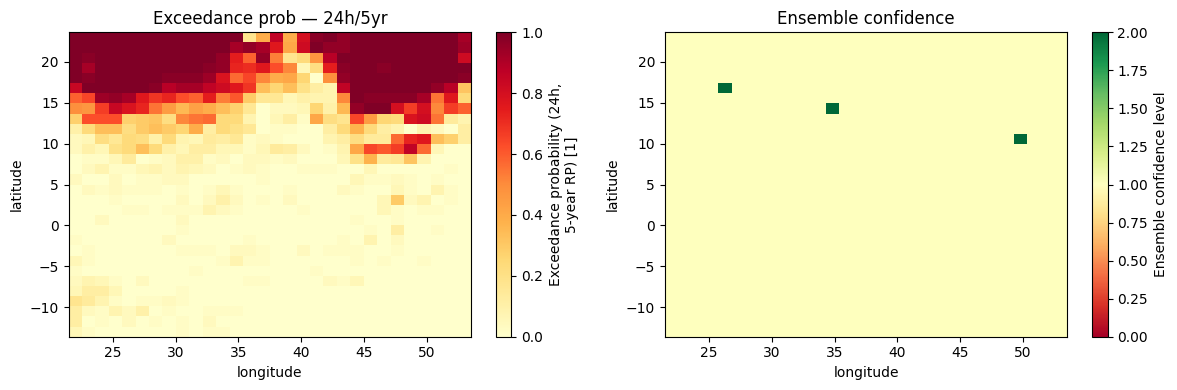

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p.plot(ax=axes[0], cmap="YlOrRd", vmin=0, vmax=1)
axes[0].set_title("Exceedance prob — 24h/5yr")
conf.plot(ax=axes[1], cmap="RdYlGn", vmin=0, vmax=2)
axes[1].set_title("Ensemble confidence")
fig.tight_layout()
plt.show()

## 2.6 Exceedance Zarr store

In [25]:
try:
    exc_ds = xr.open_zarr(
        cfg.outputs.exceedance_store_uri,
        consolidated=False,
        storage_options=STORAGE_OPTIONS,
    )
    print("Exceedance store dimensions:")
    print(exc_ds)
    dates = exc_ds.coords.get("date", exc_ds.coords.get("time", None))
    if dates is not None:
        print(f"Date range: {str(dates.values[0])[:10]} → {str(dates.values[-1])[:10]}")
except Exception as exc:
    print("C2 store not yet available — run gik-icechain exceedance first")
    print(f"({type(exc).__name__}: {exc})")

Exceedance store dimensions:
<xarray.Dataset> Size: 11MB
Dimensions:              (date: 3, latitude: 159, longitude: 137, window: 7,
                          return_period: 6)
Coordinates:
  * date                 (date) datetime64[ns] 24B 2025-11-19 ... 2025-11-18
  * latitude             (latitude) float32 636B 25.0 24.75 ... -14.25 -14.5
  * longitude            (longitude) float32 548B 20.0 20.25 20.5 ... 53.75 54.0
  * window               (window) int64 56B 3 6 12 24 48 72 168
  * return_period        (return_period) int64 48B 2 5 10 20 40 100
    duration             (window) <U3 84B dask.array<chunksize=(7,), meta=np.ndarray>
Data variables:
    ensemble_confidence  (date, latitude, longitude) int8 65kB dask.array<chunksize=(2, 100, 100), meta=np.ndarray>
    exceedance_prob      (date, window, return_period, latitude, longitude) float32 11MB dask.array<chunksize=(2, 7, 6, 100, 100), meta=np.ndarray>
Attributes:
    title:        GIK-IceChain exceedance probabilities
    sour